In [83]:
import scipy.io
import numpy as np

# 載入 .mat 檔
mat = scipy.io.loadmat('Final11Pattern.mat')

# 過濾掉 scipy 自動加入的 metadata（以 _ 開頭的 key）
print("=" * 50)
print("檔案內容")
print("=" * 50)

for key, val in mat.items():
    if not key.startswith('_'):
        print(f"\n變數名稱: {key}")
        print(f"資料類型: {type(val).__name__}")
        
        # if isinstance(val, np.ndarray):
        #     print(f"陣列形狀: {val.shape}")
        #     print(f"資料精度: {val.dtype}")
        #     print(f"\n內容:")
        #     print(val)

# 取得第 1 個矩陣（index 從 0 開始）
print(mat['Matrix'][:, :, 0])

# 迴圈印出全部 11 個矩陣
for i in range(11):
    print(f"\n--- 第 {i+1} 個矩陣 ---")
    print(mat['Matrix'][:, :, i])

檔案內容

變數名稱: Matrix
資料類型: ndarray
[[ 6.5516178   0.43827359 -0.52172121]
 [ 0.43827359  0.1703769   0.36873055]
 [-0.52172121  0.36873055  1.68074336]]

--- 第 1 個矩陣 ---
[[ 6.5516178   0.43827359 -0.52172121]
 [ 0.43827359  0.1703769   0.36873055]
 [-0.52172121  0.36873055  1.68074336]]

--- 第 2 個矩陣 ---
[[ 1.02827641  0.95816465 -0.41053392]
 [ 0.95816465  1.36521954 -0.94905376]
 [-0.41053392 -0.94905376  1.01855396]]

--- 第 3 個矩陣 ---
[[ 1.4249516   0.17022287 -0.75057074]
 [ 0.17022287  1.75920185 -1.39579117]
 [-0.75057074 -1.39579117  1.47384017]]

--- 第 4 個矩陣 ---
[[ 2.04985484 -2.39385589 -0.23641338]
 [-2.39385589  3.47323341 -0.02300423]
 [-0.23641338 -0.02300423  0.16629091]]

--- 第 5 個矩陣 ---
[[1.63846015 1.14360557 0.18043919]
 [1.14360557 2.7096744  1.77889824]
 [0.18043919 1.77889824 1.49095824]]

--- 第 6 個矩陣 ---
[[ 2.71206739  0.63129848 -1.90150804]
 [ 0.63129848  1.31576615 -1.12064192]
 [-1.90150804 -1.12064192  2.26644206]]

--- 第 7 個矩陣 ---
[[ 2.44381295 -1.70905675 -2.33

In [91]:
# 假設你已經讀取了檔案
# mat = sio.loadmat('Final11Pattern.mat')
matrices = mat['Matrix']  # shape: (3, 3, 11)

# 為了儲存標準答案的 list
golden_eigenvalues = []
golden_eigenvectors = []

# 遍歷 11 個矩陣
for i in range(11):
    A = matrices[:, :, i]
    
    # 使用 eigh 來解對稱實數矩陣 (會自動回傳實數)
    eigenvalues, eigenvectors = np.linalg.eigh(A)
    
    # 將特徵值由大到小排序，並同步排序特徵向量 (對齊 RMSE 基準)
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_evals = eigenvalues[sorted_indices]
    sorted_evecs = eigenvectors[:, sorted_indices]
    
    golden_eigenvalues.append(sorted_evals)
    golden_eigenvectors.append(sorted_evecs)

print("✅ 已成功計算 11 組矩陣的標準特徵值與特徵向量 (Golden Model)！")
# 可以印出第 8 組 (Index 7) 來看看
print(f"Matrix 8 Eigenvalues: \n{golden_eigenvalues[7]}")
print(f"Matrix 8 Eigenvectors: \n{golden_eigenvectors[7]}")


✅ 已成功計算 11 組矩陣的標準特徵值與特徵向量 (Golden Model)！
Matrix 8 Eigenvalues: 
[7.24685273e+00 1.29717242e+00 1.52791938e-04]
Matrix 8 Eigenvectors: 
[[-0.09583639  0.56856005  0.81704031]
 [ 0.20073193  0.81499421 -0.54359096]
 [ 0.97494722 -0.11191029  0.19223426]]


In [85]:
import math

def cordic_vectoring(x, y, stages=12):
    """ CORDIC 向量模式：負責把 y 歸零，並回傳微旋轉方向 (d_list) """
    d_list = []
    x_curr, y_curr = x, y
    for i in range(stages):
        # 決定旋轉方向：如果 y >= 0，順時針轉 (d = -1)；否則逆時針轉 (d = 1)
        d = -1 if y_curr >= 0 else 1
        d_list.append(d)
        
        # Shift-and-Add 運算
        x_next = x_curr - d * y_curr * (2**(-i))
        y_next = y_curr + d * x_curr * (2**(-i))
        x_curr, y_curr = x_next, y_next
        
    # 補償縮放因子 (Scaling Factor)
    K = np.prod([1.0 / np.sqrt(1 + 2**(-2*i)) for i in range(stages)])
    return x_curr * K, y_curr * K, d_list

def cordic_rotation(x, y, d_list):
    """ CORDIC 旋轉模式：接收 d_list，對輸入資料執行相同的微旋轉 """
    x_curr, y_curr = x, y
    stages = len(d_list)
    for i in range(stages):
        d = d_list[i]
        x_next = x_curr - d * y_curr * (2**(-i))
        y_next = y_curr + d * x_curr * (2**(-i))
        x_curr, y_curr = x_next, y_next
        
    # 補償縮放因子 (Scaling Factor)
    K = np.prod([1.0 / np.sqrt(1 + 2**(-2*i)) for i in range(stages)])
    return x_curr * K, y_curr * K

def systolic_qrd_3x3(A, stages=16):
    """ 模擬 3x3 三角形收縮陣列的 QR 分解 """
    R = A.copy()
    Qt = np.eye(3) # 記錄旋轉歷史，即為 Q^T
    
    # 步驟 (i): 使用 R[0,0] 消除 R[1,0]
    R[0,0], R[1,0], d1 = cordic_vectoring(R[0,0], R[1,0], stages)
    for j in range(1, 3): R[0,j], R[1,j] = cordic_rotation(R[0,j], R[1,j], d1)
    for j in range(3):    Qt[0,j], Qt[1,j] = cordic_rotation(Qt[0,j], Qt[1,j], d1)
        
    # 步驟 (ii): 使用 R[0,0] 消除 R[2,0]
    R[0,0], R[2,0], d2 = cordic_vectoring(R[0,0], R[2,0], stages)
    for j in range(1, 3): R[0,j], R[2,j] = cordic_rotation(R[0,j], R[2,j], d2)
    for j in range(3):    Qt[0,j], Qt[2,j] = cordic_rotation(Qt[0,j], Qt[2,j], d2)
        
    # 步驟 (iii): 使用 R[1,1] 消除 R[2,1]
    R[1,1], R[2,1], d3 = cordic_vectoring(R[1,1], R[2,1], stages)
    for j in range(2, 3): R[1,j], R[2,j] = cordic_rotation(R[1,j], R[2,j], d3)
    for j in range(3):    Qt[1,j], Qt[2,j] = cordic_rotation(Qt[1,j], Qt[2,j], d3)
    
    # 強制清零（硬體中自然為 0 或趨近 0 的截斷誤差）
    R[1,0] = R[2,0] = R[2,1] = 0.0
    
    # 回傳正交矩陣 Q (為 Qt 的轉置) 與上三角矩陣 R
    return Qt.T, R

def calc_rmse_with_alignment(val_std, vec_std, val_est, vec_est):
    """ 對齊排序與正負號後，計算 RMSE """
    # 1. 將預測結果由大到小排序
    idx_est = np.argsort(val_est)[::-1]
    val_est_sorted = val_est[idx_est]
    vec_est_sorted = vec_est[:, idx_est]
    
    # 2. 對齊特徵向量的正負號 (如果向量內積為負，代表方向相反，乘上 -1)
    for i in range(3):
        if np.dot(vec_std[:, i], vec_est_sorted[:, i]) < 0:
            vec_est_sorted[:, i] = -vec_est_sorted[:, i]
            
    # 3. 計算 RMSE
    rmse_val = np.sqrt(np.mean((val_std - val_est_sorted)**2))
    rmse_vec = np.sqrt(np.mean((vec_std - vec_est_sorted)**2))
    return rmse_val, rmse_vec

# ================= 執行 11 組測資的測試 =================

ITERATIONS = 7
STAGES = 12  # CORDIC 級數，後續你可以修改此數值掃描 RMSE

for i in range(11):
    A = matrices[:, :, i]
    T = A.copy()
    U = np.eye(3) # 儲存特徵向量的累積矩陣
    
    # 執行 4 次 Iterative QR
    for _ in range(ITERATIONS):
        Q, R = systolic_qrd_3x3(T, STAGES)
        T = R @ Q   # 下一回合的 T (硬體中是由 R^T 餵入陣列乘上 Q^T 後再轉置)
        U = U @ Q   # 累積特徵向量
        
    est_eigenvalues = np.diag(T)
    est_eigenvectors = U
    
    # 呼叫 Block 1 的標準答案來對答案
    rmse_val, rmse_vec = calc_rmse_with_alignment(
        golden_eigenvalues[i], golden_eigenvectors[i], 
        est_eigenvalues, est_eigenvectors
    )
    
    print(f"Pattern {i+1:02d} | Val RMSE: {rmse_val:.2e} | Vec RMSE: {rmse_vec:.2e}")

    # if i == 7:
    #     print("est_eigenvalues:", est_eigenvalues)
    #     print("est_eigenvectors:\n", est_eigenvectors)

Pattern 01 | Val RMSE: 1.81e-04 | Vec RMSE: 1.01e-03
Pattern 02 | Val RMSE: 1.97e-04 | Vec RMSE: 4.20e-04
Pattern 03 | Val RMSE: 2.04e-04 | Vec RMSE: 2.66e-03
Pattern 04 | Val RMSE: 8.77e-05 | Vec RMSE: 3.95e-04
Pattern 05 | Val RMSE: 6.20e-04 | Vec RMSE: 9.98e-04
Pattern 06 | Val RMSE: 2.51e-04 | Vec RMSE: 1.07e-03
Pattern 07 | Val RMSE: 6.06e-04 | Vec RMSE: 6.05e-04
Pattern 08 | Val RMSE: 5.39e-04 | Vec RMSE: 6.04e-04
Pattern 09 | Val RMSE: 5.99e-04 | Vec RMSE: 6.56e-03
Pattern 10 | Val RMSE: 7.33e-04 | Vec RMSE: 1.40e-03
Pattern 11 | Val RMSE: 4.26e-04 | Vec RMSE: 8.47e-04


In [86]:
#Rayleigh quotient shift + deflation
import numpy as np

# ================= 1. CORDIC 核心模組 (已包含象限映射修復) =================

def cordic_vectoring(x, y, stages=12):
    """ CORDIC 向量模式：加入二、三象限的 Initial Mapping """
    d_list = []
    x_curr, y_curr = x, y
    
    # 如果 x 為負 (二、三象限)，先翻轉 180 度
    is_flipped = False
    if x_curr < 0:
        x_curr, y_curr = -x_curr, -y_curr
        is_flipped = True
        
    for i in range(stages):
        d = -1 if y_curr >= 0 else 1
        d_list.append(d)
        
        x_next = x_curr - d * y_curr * (2**(-i))
        y_next = y_curr + d * x_curr * (2**(-i))
        x_curr, y_curr = x_next, y_next
        
    K = np.prod([1.0 / np.sqrt(1 + 2**(-2*i)) for i in range(stages)])
    x_out, y_out = x_curr * K, y_curr * K
    
    # 計算完畢後翻轉回來
    if is_flipped:
        x_out, y_out = -x_out, -y_out
        
    return x_out, y_out, (is_flipped, d_list)

def cordic_rotation(x, y, op_info):
    """ CORDIC 旋轉模式：同步執行 Initial Mapping """
    is_flipped, d_list = op_info
    x_curr, y_curr = x, y
    
    if is_flipped:
        x_curr, y_curr = -x_curr, -y_curr
        
    stages = len(d_list)
    for i in range(stages):
        d = d_list[i]
        x_next = x_curr - d * y_curr * (2**(-i))
        y_next = y_curr + d * x_curr * (2**(-i))
        x_curr, y_curr = x_next, y_next
        
    K = np.prod([1.0 / np.sqrt(1 + 2**(-2*i)) for i in range(stages)])
    x_out, y_out = x_curr * K, y_curr * K
    
    if is_flipped:
        x_out, y_out = -x_out, -y_out
        
    return x_out, y_out

# ================= 2. Systolic QR 分解模組 =================

def systolic_qrd_3x3(A, stages=12):
    """ 3x3 QR 分解 """
    R = A.copy()
    Qt = np.eye(3)
    
    # 消除 R[1,0]
    R[0,0], R[1,0], d1 = cordic_vectoring(R[0,0], R[1,0], stages)
    for j in range(1, 3): R[0,j], R[1,j] = cordic_rotation(R[0,j], R[1,j], d1)
    for j in range(3):    Qt[0,j], Qt[1,j] = cordic_rotation(Qt[0,j], Qt[1,j], d1)
        
    # 消除 R[2,0]
    R[0,0], R[2,0], d2 = cordic_vectoring(R[0,0], R[2,0], stages)
    for j in range(1, 3): R[0,j], R[2,j] = cordic_rotation(R[0,j], R[2,j], d2)
    for j in range(3):    Qt[0,j], Qt[2,j] = cordic_rotation(Qt[0,j], Qt[2,j], d2)
        
    # 消除 R[2,1]
    R[1,1], R[2,1], d3 = cordic_vectoring(R[1,1], R[2,1], stages)
    for j in range(2, 3): R[1,j], R[2,j] = cordic_rotation(R[1,j], R[2,j], d3)
    for j in range(3):    Qt[1,j], Qt[2,j] = cordic_rotation(Qt[1,j], Qt[2,j], d3)
    
    R[1,0] = R[2,0] = R[2,1] = 0.0
    return Qt.T, R

def systolic_qrd_2x2(A, stages=12):
    """ 降維後使用的 2x2 QR 分解 """
    R = A.copy()
    Qt = np.eye(2)
    
    # 消除 R[1,0]
    R[0,0], R[1,0], d1 = cordic_vectoring(R[0,0], R[1,0], stages)
    for j in range(1, 2): R[0,j], R[1,j] = cordic_rotation(R[0,j], R[1,j], d1)
    for j in range(2):    Qt[0,j], Qt[1,j] = cordic_rotation(Qt[0,j], Qt[1,j], d1)
        
    R[1,0] = 0.0
    return Qt.T, R

# ================= 3. 主測試迴圈 (結合 Shift + Deflation) =================

ITERATIONS = 7
STAGES = 12
DEFLATION_TOL = 1e-3  # 降維判定閾值

for i in range(11):
    A = matrices[:, :, i]
    T = A.copy()
    U = np.eye(3)
    
    is_deflated = False # 紀錄是否已經完成 3x3 到 2x2 的降維
    
    for _ in range(ITERATIONS):
        # 判斷是否需要降維：觀察次對角線元素 T[2, 1]
        if not is_deflated and abs(T[2, 1]) < DEFLATION_TOL:
            is_deflated = True
            
        if not is_deflated:
            # 尚未降維：執行完整的 3x3 運算，平移量為 T[2, 2]
            mu = T[2, 2]
            T_shifted = T - mu * np.eye(3)
            Q, R = systolic_qrd_3x3(T_shifted, STAGES)
            T = R @ Q + mu * np.eye(3)
            U = U @ Q
        else:
            # 已經降維：鎖死第 3 行與第 3 列，只處理左上角的 2x2 子矩陣
            # 此時的平移量改為 2x2 子矩陣的右下角，即 T[1, 1]
            mu = T[1, 1]
            T_sub = T[0:2, 0:2]
            T_shifted = T_sub - mu * np.eye(2)
            
            Q_sub, R_sub = systolic_qrd_2x2(T_shifted, STAGES)
            
            # 更新 2x2 子矩陣
            T[0:2, 0:2] = R_sub @ Q_sub + mu * np.eye(2)
            
            # 將 2x2 的 Q 矩陣擴充回 3x3 以更新特徵向量 U
            Q_full = np.eye(3)
            Q_full[0:2, 0:2] = Q_sub
            U = U @ Q_full
            
    est_eigenvalues = np.diag(T)
    est_eigenvectors = U
    
    # 呼叫標準答案來對答案 (假設 calc_rmse_with_alignment 已定義)
    rmse_val, rmse_vec = calc_rmse_with_alignment(
        golden_eigenvalues[i], golden_eigenvectors[i], 
        est_eigenvalues, est_eigenvectors
    )
    
    print(f"Pattern {i+1:02d} | Val RMSE: {rmse_val:.2e} | Vec RMSE: {rmse_vec:.2e}")

Pattern 01 | Val RMSE: 1.19e-04 | Vec RMSE: 3.08e-04
Pattern 02 | Val RMSE: 1.56e-04 | Vec RMSE: 5.23e-04
Pattern 03 | Val RMSE: 1.33e-04 | Vec RMSE: 3.59e-04
Pattern 04 | Val RMSE: 4.75e-04 | Vec RMSE: 1.82e-03
Pattern 05 | Val RMSE: 2.74e-04 | Vec RMSE: 3.96e-04
Pattern 06 | Val RMSE: 1.45e-04 | Vec RMSE: 4.61e-04
Pattern 07 | Val RMSE: 8.16e-04 | Vec RMSE: 8.70e-04
Pattern 08 | Val RMSE: 5.45e-04 | Vec RMSE: 4.42e-04
Pattern 09 | Val RMSE: 3.46e-04 | Vec RMSE: 2.57e-04
Pattern 10 | Val RMSE: 1.59e-05 | Vec RMSE: 2.28e-04
Pattern 11 | Val RMSE: 4.67e-04 | Vec RMSE: 2.78e-04


=== S(N) CSD 分析 (級數=12, 精度=14 bits) ===
理想 S(N) 值 : 0.607253
CSD S(N) 值  : 0.607239
CSD 表示法   : +0+00-00-00-0+ (左側為 MSB, 右側為 LSB，對應 2^-1 到 2^-14)
非零位元數   : 6
需要加/減法器: 5 個

=== 啟動掃描 ===
整數字長固定為: 6 bits
縮放因子小數字長固定為: 14 bits (使用 5 個加法器)

Frac Bits:  8 (Total WL: 14) | Worst Val RMSE: 1.86e-01 | Worst Vec RMSE: 4.79e-02
Frac Bits:  9 (Total WL: 15) | Worst Val RMSE: 9.63e-02 | Worst Vec RMSE: 2.60e-02
Frac Bits: 10 (Total WL: 16) | Worst Val RMSE: 5.12e-02 | Worst Vec RMSE: 1.46e-02
Frac Bits: 11 (Total WL: 17) | Worst Val RMSE: 2.11e-02 | Worst Vec RMSE: 7.38e-03
Frac Bits: 12 (Total WL: 18) | Worst Val RMSE: 9.11e-03 | Worst Vec RMSE: 7.08e-03
Frac Bits: 13 (Total WL: 19) | Worst Val RMSE: 3.28e-03 | Worst Vec RMSE: 6.57e-03
Frac Bits: 14 (Total WL: 20) | Worst Val RMSE: 3.37e-03 | Worst Vec RMSE: 6.60e-03
Frac Bits: 15 (Total WL: 21) | Worst Val RMSE: 4.36e-03 | Worst Vec RMSE: 6.64e-03
Frac Bits: 16 (Total WL: 22) | Worst Val RMSE: 4.27e-03 | Worst Vec RMSE: 6.67e-03
Frac Bits: 17 (Tot

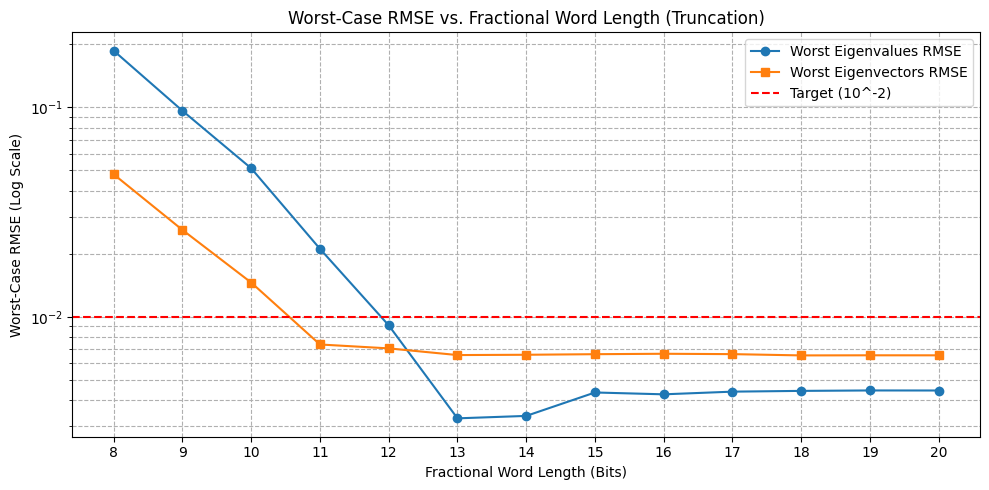

In [87]:
import matplotlib.pyplot as plt

# =====================================================================
# 1. CSD 與縮放因子 (Scaling Factor) 分析函數
# =====================================================================
def get_scaling_factor_csd(stages, s_frac_bits):
    """
    輸入: CORDIC 級數 (stages), 縮放因子的小數位元數 (s_frac_bits)
    輸出: CSD 陣列 (從 LSB 到 MSB), 加法器數量, 實際量化後的 S(N) 值
    """
    # 計算理想的縮放因子 S(N)
    ideal_K = np.prod([1.0 / np.sqrt(1 + 2**(-2*i)) for i in range(stages)])
    
    # 將 S(N) 放大並四捨五入為整數，準備進行 CSD 轉換
    N = int(np.round(ideal_K * (2**s_frac_bits)))
    
    csd = []
    temp_N = N
    # CSD 轉換演算法
    while temp_N > 0:
        if temp_N % 2 == 0:
            csd.append(0)
            temp_N //= 2
        else:
            # 往前看一個 bit (Lookahead) 決定要加 1 還是減 1
            lookahead = (temp_N // 2) % 2
            if lookahead == 1:
                csd.append(-1)
                temp_N = (temp_N // 2) + 1
            else:
                csd.append(1)
                temp_N //= 2
                
    # 計算非零項的數量
    non_zeros = sum(1 for bit in csd if bit != 0)
    # 加法器數量 = 非零項數量 - 1 (如果非零項為 0，則不需要加法器)
    adders = max(0, non_zeros - 1)
    
    # 建立視覺化的 CSD 字串 (MSB -> LSB)
    csd_str_visual = "".join(['+' if b == 1 else '-' if b == -1 else '0' for b in reversed(csd)])
    
    # 計算 CSD 實際代表的值 (驗證用)
    csd_value = sum(b * (2**(i - s_frac_bits)) for i, b in enumerate(csd))
    
    print(f"=== S(N) CSD 分析 (級數={stages}, 精度={s_frac_bits} bits) ===")
    print(f"理想 S(N) 值 : {ideal_K:.6f}")
    print(f"CSD S(N) 值  : {csd_value:.6f}")
    print(f"CSD 表示法   : {csd_str_visual} (左側為 MSB, 右側為 LSB，對應 2^{len(csd)-1-s_frac_bits} 到 2^{-s_frac_bits})")
    print(f"非零位元數   : {non_zeros}")
    print(f"需要加/減法器: {adders} 個\n")
    
    return csd, adders, csd_value

# =====================================================================
# 2. 截斷量化與 Bit-True CORDIC 實作
# =====================================================================
def truncate(val, frac_bits):
    """ 模擬硬體二補數截斷 (直接捨去 LSB) """
    return np.floor(val * (2**frac_bits)) / (2**frac_bits)

def round_half_up(val, frac_bits):
    """ 模擬硬體的 Rounding (加 0.5 LSB 後截斷) """
    # 加上 0.5 * 2^(-frac_bits)，然後再做 floor
    return np.floor(val * (2**frac_bits) + 0.5) / (2**frac_bits)
    
def apply_csd_scaling(x, csd_array, s_frac_bits, data_frac_bits):
    """ 使用 CSD 進行縮放因子的乘法 (Shift-and-Add)，並在每一步保持截斷 """
    result = 0.0
    # csd_array 索引 i 對應的權重為 2^(i - s_frac_bits)
    for i, bit in enumerate(csd_array):
        if bit != 0:
            # 硬體中的位移操作 (這裡統一用浮點數結合 truncate 模擬)
            shifted_x = truncate(x * (2**(i - s_frac_bits)), data_frac_bits)
            if bit == 1:
                result = truncate(result + shifted_x, data_frac_bits)
            elif bit == -1:
                result = truncate(result - shifted_x, data_frac_bits)
    return result

def cordic_vectoring_quantized(x, y, stages, data_frac_bits, csd_array, s_frac_bits):
    x = truncate(x, data_frac_bits)
    y = truncate(y, data_frac_bits)
    d_list = []
    
    for i in range(stages):
        d = -1 if y >= 0 else 1
        d_list.append(d)
        
        x_shifted = truncate(x * (2**(-i)), data_frac_bits)
        y_shifted = truncate(y * (2**(-i)), data_frac_bits)
        
        x_next = truncate(x - d * y_shifted, data_frac_bits)
        y_next = truncate(y + d * x_shifted, data_frac_bits)
        x, y = x_next, y_next
        
    # 套用 CSD 縮放
    x_scaled = apply_csd_scaling(x, csd_array, s_frac_bits, data_frac_bits)
    y_scaled = apply_csd_scaling(y, csd_array, s_frac_bits, data_frac_bits)
    return x_scaled, y_scaled, d_list

def cordic_rotation_quantized(x, y, d_list, data_frac_bits, csd_array, s_frac_bits):
    x = truncate(x, data_frac_bits)
    y = truncate(y, data_frac_bits)
    
    for i, d in enumerate(d_list):
        x_shifted = truncate(x * (2**(-i)), data_frac_bits)
        y_shifted = truncate(y * (2**(-i)), data_frac_bits)
        
        x_next = truncate(x - d * y_shifted, data_frac_bits)
        y_next = truncate(y + d * x_shifted, data_frac_bits)
        x, y = x_next, y_next
        
    x_scaled = apply_csd_scaling(x, csd_array, s_frac_bits, data_frac_bits)
    y_scaled = apply_csd_scaling(y, csd_array, s_frac_bits, data_frac_bits)
    return x_scaled, y_scaled

# =====================================================================
# 2.5 完整模擬硬體單次 Iteration (QR 分解 + 矩陣旋轉更新)
# =====================================================================
def systolic_iteration_quantized(T, U, stages, data_frac_bits, csd_array, s_frac_bits):
    R = T.copy()
    
    # ==========================================
    # Phase 1: QRD (硬體的 Vectoring Mode)
    # 紀錄各 PE 的旋轉方向 (d1, d2, d3)
    # ==========================================
    # PE11
    R[0,0], R[1,0], d1 = cordic_vectoring_quantized(R[0,0], R[1,0], stages, data_frac_bits, csd_array, s_frac_bits)
    for j in range(1, 3): 
        R[0,j], R[1,j] = cordic_rotation_quantized(R[0,j], R[1,j], d1, data_frac_bits, csd_array, s_frac_bits)
        
    # PE12
    R[0,0], R[2,0], d2 = cordic_vectoring_quantized(R[0,0], R[2,0], stages, data_frac_bits, csd_array, s_frac_bits)
    for j in range(1, 3): 
        R[0,j], R[2,j] = cordic_rotation_quantized(R[0,j], R[2,j], d2, data_frac_bits, csd_array, s_frac_bits)
        
    # PE22
    R[1,1], R[2,1], d3 = cordic_vectoring_quantized(R[1,1], R[2,1], stages, data_frac_bits, csd_array, s_frac_bits)
    for j in range(2, 3): 
        R[1,j], R[2,j] = cordic_rotation_quantized(R[1,j], R[2,j], d3, data_frac_bits, csd_array, s_frac_bits)
    
    R[1,0] = R[2,0] = R[2,1] = 0.0

    # ==========================================
    # Phase 2: Matrix Update (硬體的 ST_ROT_PIPE 階段)
    # 100% 模擬硬體：將 R^T 和 U^T 送入 CORDIC 進行旋轉
    # ==========================================
    T_next_T = R.T.copy()
    U_next_T = U.T.copy()
    
    # PE11 應用儲存的角度 d1 (對 T^T 和 U^T 的前兩 Row 操作)
    for j in range(3):
        T_next_T[0,j], T_next_T[1,j] = cordic_rotation_quantized(T_next_T[0,j], T_next_T[1,j], d1, data_frac_bits, csd_array, s_frac_bits)
        U_next_T[0,j], U_next_T[1,j] = cordic_rotation_quantized(U_next_T[0,j], U_next_T[1,j], d1, data_frac_bits, csd_array, s_frac_bits)
        
    # PE12 應用儲存的角度 d2
    for j in range(3):
        T_next_T[0,j], T_next_T[2,j] = cordic_rotation_quantized(T_next_T[0,j], T_next_T[2,j], d2, data_frac_bits, csd_array, s_frac_bits)
        U_next_T[0,j], U_next_T[2,j] = cordic_rotation_quantized(U_next_T[0,j], U_next_T[2,j], d2, data_frac_bits, csd_array, s_frac_bits)
        
    # PE22 應用儲存的角度 d3
    for j in range(3):
        T_next_T[1,j], T_next_T[2,j] = cordic_rotation_quantized(T_next_T[1,j], T_next_T[2,j], d3, data_frac_bits, csd_array, s_frac_bits)
        U_next_T[1,j], U_next_T[2,j] = cordic_rotation_quantized(U_next_T[1,j], U_next_T[2,j], d3, data_frac_bits, csd_array, s_frac_bits)
        
    # 轉置回來，得到 T_next 與 U_next
    return T_next_T.T, U_next_T.T


# =====================================================================
# 3. 主迴圈：獨立調整 S(N) 精度、掃描小數字長、計算最糟 RMSE
# =====================================================================

INT_BITS = 6 
S_FRAC_BITS = 14 

# 提前計算好固定的 CSD 陣列
csd_array, num_adders, actual_scale = get_scaling_factor_csd(STAGES, S_FRAC_BITS)

# =====================================================================
# 2.6 Matrix(:,:,8) bit-true eigenresult @ frac_bits = 12 (Q6.12)
# =====================================================================
MATRIX8_IDX = 7          # Matrix(:,:,8) — 1-based index 8
FRAC_BITS_REF = 12       # Q6.12, matches RTL DATA_FRAC_BITS

def to_fixed_int(val, frac_bits):
    """Truncate to Q-format and return 18-bit-style signed integer."""
    q = truncate(val, frac_bits)
    return int(np.floor(q * (2**frac_bits)))

frac_bits = FRAC_BITS_REF
A8 = truncate(matrices[:, :, MATRIX8_IDX].copy(), frac_bits)
T8 = A8.copy()
U8 = np.eye(3)

for _ in range(ITERATIONS):
    T8, U8 = systolic_iteration_quantized(
        T8, U8, STAGES, frac_bits, csd_array, S_FRAC_BITS
    )

eigvals8 = np.diag(T8)
val_rmse8, vec_rmse8 = calc_rmse_with_alignment(
    golden_eigenvalues[MATRIX8_IDX],
    golden_eigenvectors[MATRIX8_IDX],
    eigvals8,
    U8,
)

# print("=" * 60)
# print(f"Matrix(:,:,8) bit-true result @ frac_bits = {FRAC_BITS_REF}")
# print("=" * 60)
# print("Quantized input A:")
# print(A8)
# print()
# print("Eigenvalues (float, truncated Q5.13):")
# for i, v in enumerate(eigvals8):
#     print(f"  lambda[{i}] = {v:+.10f}   fixed = {to_fixed_int(v, frac_bits):>6d}")
# print()
# print("Eigenvector matrix U (rows = eigenvectors):")
# print(U8)
# print()
# print("U rows as fixed-point integers:")
# for row in range(3):
#     ints = [to_fixed_int(U8[row, col], frac_bits) for col in range(3)]
#     print(f"  U_row[{row}] = {ints}")
# print()
# print("Golden (np.linalg.eigh, float):")
# print(f"  eigenvalues  = {golden_eigenvalues[MATRIX8_IDX]}")
# print("  eigenvectors (columns):")
# print(golden_eigenvectors[MATRIX8_IDX])
# print()
# print(f"RMSE vs golden: val = {val_rmse8:.6e}, vec = {vec_rmse8:.6e}")
# print("=" * 60)
# print()

frac_bits_list = range(8, 21)
worst_rmse_vals_list = []
worst_rmse_vecs_list = []

print(f"=== 啟動掃描 ===")
print(f"整數字長固定為: {INT_BITS} bits")
print(f"縮放因子小數字長固定為: {S_FRAC_BITS} bits (使用 {num_adders} 個加法器)\n")

for frac_bits in frac_bits_list:
    worst_val_rmse = 0.0
    worst_vec_rmse = 0.0
    
    for i in range(11):
        # 初始矩陣量化
        A = truncate(matrices[:, :, i].copy(), frac_bits)
        T = A.copy()
        U = np.eye(3) 
        
        for _ in range(ITERATIONS):
            # 直接呼叫我們剛寫好的，完全對齊硬體架構的 Iteration 函數
            T, U = systolic_iteration_quantized(T, U, STAGES, frac_bits, csd_array, S_FRAC_BITS)
            
        est_vals = np.diag(T)
        est_vecs = U
        
        val_rmse, vec_rmse = calc_rmse_with_alignment(
            golden_eigenvalues[i], golden_eigenvectors[i], est_vals, est_vecs
        )
        
        worst_val_rmse = max(worst_val_rmse, val_rmse)
        worst_vec_rmse = max(worst_vec_rmse, vec_rmse)
        
    worst_rmse_vals_list.append(worst_val_rmse)
    worst_rmse_vecs_list.append(worst_vec_rmse)
    
    total_wl = INT_BITS + frac_bits
    print(f"Frac Bits: {frac_bits:2d} (Total WL: {total_wl:2d}) | Worst Val RMSE: {worst_val_rmse:.2e} | Worst Vec RMSE: {worst_vec_rmse:.2e}")

# =====================================================================
# 4. 繪圖 (X軸改為小數字長)
# =====================================================================
plt.figure(figsize=(10, 5))
plt.plot(frac_bits_list, worst_rmse_vals_list, marker='o', label='Worst Eigenvalues RMSE')
plt.plot(frac_bits_list, worst_rmse_vecs_list, marker='s', label='Worst Eigenvectors RMSE')
plt.axhline(y=1e-2, color='r', linestyle='--', label='Target (10^-2)')

plt.yscale('log')
plt.xticks(frac_bits_list)
plt.xlabel('Fractional Word Length (Bits)')
plt.ylabel('Worst-Case RMSE (Log Scale)')
plt.title('Worst-Case RMSE vs. Fractional Word Length (Truncation)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

=== S(N) CSD 分析 (級數=10, 精度=14 bits) ===
理想 S(N) 值 : 0.607253
CSD S(N) 值  : 0.607239
CSD 表示法   : +0+00-00-00-0+ (左側為 MSB, 右側為 LSB，對應 2^-1 到 2^-14)
非零位元數   : 6
需要加/減法器: 5 個

Integer Bit-True (Verilog-aligned) — all 11 patterns @ FRAC_BITS=11
 Pattern |     Val RMSE |     Vec RMSE | integer eigenvalues (λ0, λ1, λ2)
------------------------------------------------------------------------
Matrix  1 |   2.5798e-03 |   1.8638e-03 | ( 13582,   3556,     84)
Matrix  2 |   7.3148e-03 |   6.4068e-03 | (  5642,   1253,    126)
Matrix  3 |   7.0649e-03 |   6.9102e-03 | (  6647,   2778,    137)
Matrix  4 |   2.2357e-03 |   6.5026e-03 | ( 10775,    874,     11)
Matrix  5 |   4.7075e-03 |   6.0215e-03 | (  8961,   2934,     50)
Matrix  6 |   3.0137e-03 |   2.9550e-03 | (  9884,   2369,    633)
Matrix  7 |   7.0356e-03 |   4.0473e-03 | ( 14593,   2658,    706)
Matrix  8 |   6.4802e-03 |   6.5884e-03 | ( 14820,   2651,      6)
Matrix  9 |   7.8399e-03 |   9.1859e-03 | ( 14634,   8915,     98)
Matrix 10 

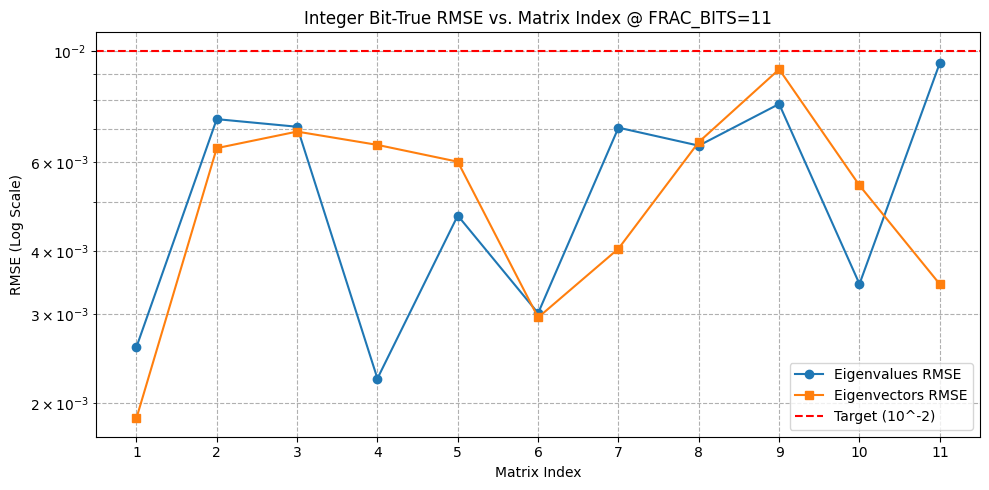


=== Integer Bit-True worst-case RMSE sweep ===
Frac Bits:  9 (Total WL: 15) | Worst Val RMSE: 2.95e-02 | Worst Vec RMSE: 1.79e-02
Frac Bits: 10 (Total WL: 16) | Worst Val RMSE: 1.48e-02 | Worst Vec RMSE: 1.45e-02
Frac Bits: 11 (Total WL: 17) | Worst Val RMSE: 9.46e-03 | Worst Vec RMSE: 9.19e-03
Frac Bits: 12 (Total WL: 18) | Worst Val RMSE: 5.11e-03 | Worst Vec RMSE: 6.07e-03
Frac Bits: 13 (Total WL: 19) | Worst Val RMSE: 4.99e-03 | Worst Vec RMSE: 6.63e-03
Frac Bits: 14 (Total WL: 20) | Worst Val RMSE: 5.21e-03 | Worst Vec RMSE: 6.60e-03
Frac Bits: 15 (Total WL: 21) | Worst Val RMSE: 4.41e-03 | Worst Vec RMSE: 6.60e-03
Frac Bits: 16 (Total WL: 22) | Worst Val RMSE: 4.83e-03 | Worst Vec RMSE: 6.54e-03


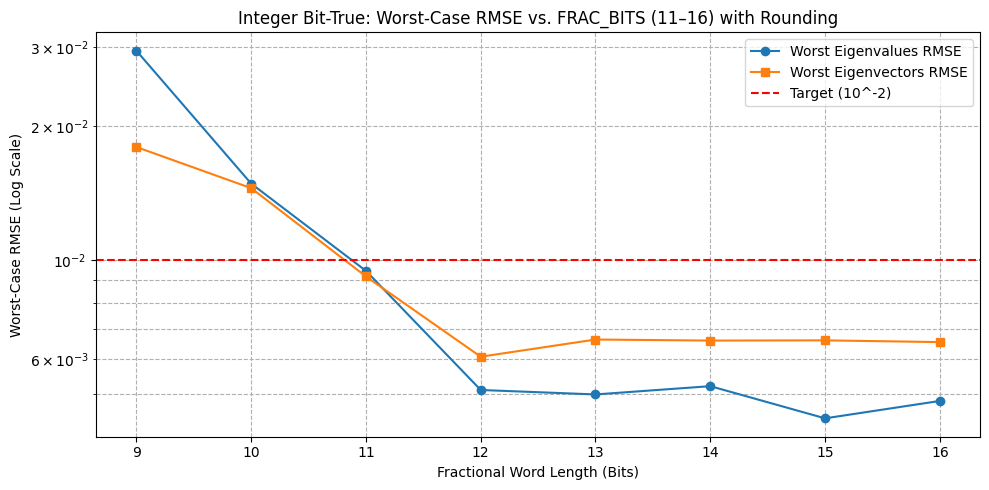


=== Integer Bit-True worst-case RMSE vs STAGES @ FRAC_BITS=11 ===
=== S(N) CSD 分析 (級數=8, 精度=14 bits) ===
理想 S(N) 值 : 0.607259
CSD S(N) 值  : 0.607239
CSD 表示法   : +0+00-00-00-0+ (左側為 MSB, 右側為 LSB，對應 2^-1 到 2^-14)
非零位元數   : 6
需要加/減法器: 5 個

Stages:  8 | Worst Val RMSE: 1.63e-02 | Worst Vec RMSE: 3.83e-02
=== S(N) CSD 分析 (級數=9, 精度=14 bits) ===
理想 S(N) 值 : 0.607254
CSD S(N) 值  : 0.607239
CSD 表示法   : +0+00-00-00-0+ (左側為 MSB, 右側為 LSB，對應 2^-1 到 2^-14)
非零位元數   : 6
需要加/減法器: 5 個

Stages:  9 | Worst Val RMSE: 1.06e-02 | Worst Vec RMSE: 1.26e-02
=== S(N) CSD 分析 (級數=10, 精度=14 bits) ===
理想 S(N) 值 : 0.607253
CSD S(N) 值  : 0.607239
CSD 表示法   : +0+00-00-00-0+ (左側為 MSB, 右側為 LSB，對應 2^-1 到 2^-14)
非零位元數   : 6
需要加/減法器: 5 個

Stages: 10 | Worst Val RMSE: 9.46e-03 | Worst Vec RMSE: 9.19e-03
=== S(N) CSD 分析 (級數=11, 精度=14 bits) ===
理想 S(N) 值 : 0.607253
CSD S(N) 值  : 0.607239
CSD 表示法   : +0+00-00-00-0+ (左側為 MSB, 右側為 LSB，對應 2^-1 到 2^-14)
非零位元數   : 6
需要加/減法器: 5 個

Stages: 11 | Worst Val RMSE: 1.18e-02 | Worst Vec RM

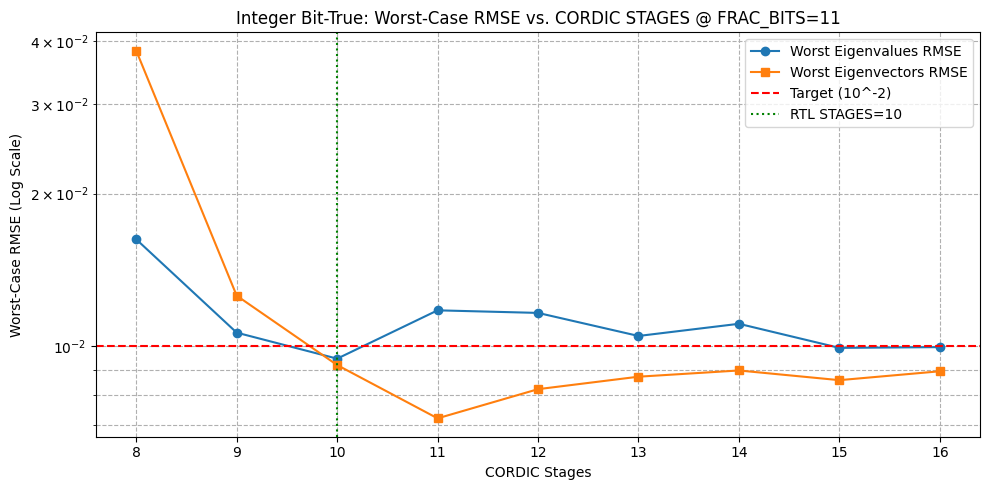


=== Integer Bit-True worst-case RMSE vs S_FRAC_BITS @ FRAC_BITS=11, STAGES=10 ===
=== S(N) CSD 分析 (級數=10, 精度=10 bits) ===
理想 S(N) 值 : 0.607253
CSD S(N) 值  : 0.607422
CSD 表示法   : +0+00-00-0 (左側為 MSB, 右側為 LSB，對應 2^-1 到 2^-10)
非零位元數   : 4
需要加/減法器: 3 個

S_FRAC_BITS: 10 | Worst Val RMSE: 5.41e-02 | Worst Vec RMSE: 9.98e-03
=== S(N) CSD 分析 (級數=10, 精度=11 bits) ===
理想 S(N) 值 : 0.607253
CSD S(N) 值  : 0.607422
CSD 表示法   : +0+00-00-00 (左側為 MSB, 右側為 LSB，對應 2^-1 到 2^-11)
非零位元數   : 4
需要加/減法器: 3 個

S_FRAC_BITS: 11 | Worst Val RMSE: 5.41e-02 | Worst Vec RMSE: 9.98e-03
=== S(N) CSD 分析 (級數=10, 精度=12 bits) ===
理想 S(N) 值 : 0.607253
CSD S(N) 值  : 0.607178
CSD 表示法   : +0+00-00-00- (左側為 MSB, 右側為 LSB，對應 2^-1 到 2^-12)
非零位元數   : 5
需要加/減法器: 4 個

S_FRAC_BITS: 12 | Worst Val RMSE: 2.61e-02 | Worst Vec RMSE: 7.37e-03
=== S(N) CSD 分析 (級數=10, 精度=13 bits) ===
理想 S(N) 值 : 0.607253
CSD S(N) 值  : 0.607300
CSD 表示法   : +0+00-00-000- (左側為 MSB, 右側為 LSB，對應 2^-1 到 2^-13)
非零位元數   : 5
需要加/減法器: 4 個

S_FRAC_BITS: 13 | Worst Val R

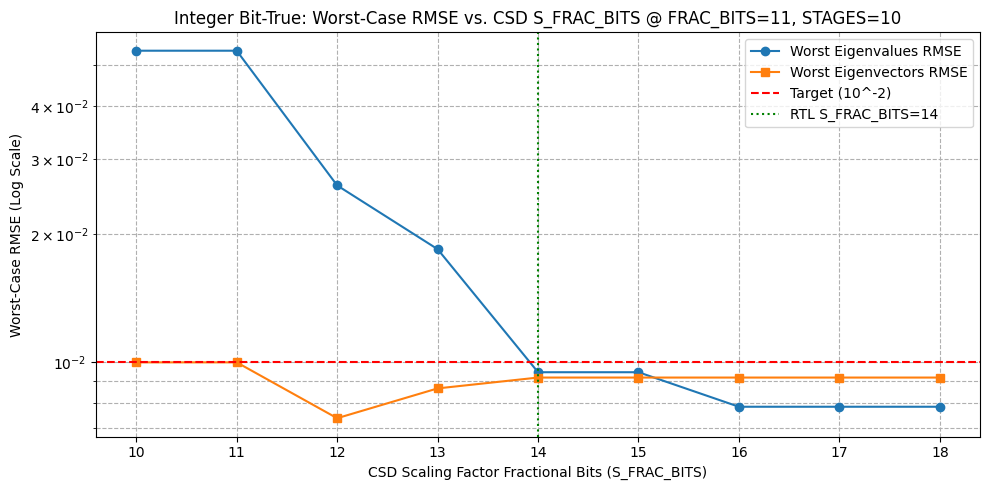

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. 硬體參數與2補數溢位處理
# =====================================================================
FRAC_BITS = 11
INT_BITS = 6
TOTAL_BITS = FRAC_BITS + INT_BITS
STAGES = 10
S_FRAC_BITS = 14 

MAX_VAL = (1 << (TOTAL_BITS - 1)) - 1  
MIN_VAL = -(1 << (TOTAL_BITS - 1))     
MASK = (1 << TOTAL_BITS) - 1           

def set_wordlength(frac_bits, int_bits=None):
    """Per-fb sweep: TOTAL_BITS = int_bits + frac_bits, refresh wrap limits."""
    global TOTAL_BITS, MAX_VAL, MIN_VAL, MASK
    if int_bits is None:
        int_bits = INT_BITS
    TOTAL_BITS = int_bits + frac_bits
    MAX_VAL = (1 << (TOTAL_BITS - 1)) - 1
    MIN_VAL = -(1 << (TOTAL_BITS - 1))
    MASK = (1 << TOTAL_BITS) - 1

def to_int18(val):
    """ 模擬硬體暫存器的截斷與 Wrap-around 溢位 """
    val = int(val) & MASK
    if val > MAX_VAL:
        val -= (1 << TOTAL_BITS)
    return val

def shift_and_round(val, shift_amt):
    """ 模擬硬體 Round Half Up (四捨五入) """
    if shift_amt <= 0:
        return val << (-shift_amt)
    # 加上 2^(shift_amt - 1) 作為四捨五入的補償 (相當於硬體加法器的 carry-in)
    rounding_add = 1 << (shift_amt - 1)
    return (val + rounding_add) >> shift_amt

# =====================================================================
# 2. CSD 與 CORDIC 的純整數實作 (導入 Rounding)
# =====================================================================
def apply_csd_int18(val, csd_array, s_frac_bits):
    result = 0
    for i, bit in enumerate(csd_array):
        if bit != 0:
            shift_amt = s_frac_bits - i
            shifted_val = shift_and_round(val, shift_amt)
            
            if bit == 1:
                result = to_int18(result + shifted_val)
            elif bit == -1:
                result = to_int18(result - shifted_val)
    return result

def cordic_vectoring_int18(x, y, stages, csd_array, s_frac_bits):
    x = to_int18(x)
    y = to_int18(y)
    d_list = []
    
    for i in range(stages):
        if y < 0:
            d = 1
        else:
            d = -1
        d_list.append(d)
        
        # 使用四捨五入取代無條件截斷
        x_shifted = shift_and_round(x, i)
        y_shifted = shift_and_round(y, i)
        
        if d == 1:
            x_next = to_int18(x - y_shifted)
            y_next = to_int18(y + x_shifted)
        else:
            x_next = to_int18(x + y_shifted)
            y_next = to_int18(y - x_shifted)
            
        x, y = x_next, y_next
        
    x_scaled = apply_csd_int18(x, csd_array, s_frac_bits)
    y_scaled = apply_csd_int18(y, csd_array, s_frac_bits)
    return x_scaled, y_scaled, d_list

def cordic_rotation_int18(x, y, d_list, csd_array, s_frac_bits):
    x = to_int18(x)
    y = to_int18(y)
    
    for i, d in enumerate(d_list):
        x_shifted = shift_and_round(x, i)
        y_shifted = shift_and_round(y, i)
        
        if d == 1:
            x_next = to_int18(x - y_shifted)
            y_next = to_int18(y + x_shifted)
        else:
            x_next = to_int18(x + y_shifted)
            y_next = to_int18(y - x_shifted)
            
        x, y = x_next, y_next
        
    x_scaled = apply_csd_int18(x, csd_array, s_frac_bits)
    y_scaled = apply_csd_int18(y, csd_array, s_frac_bits)
    return x_scaled, y_scaled

# =====================================================================
# 3. 系統級單次回圈 (100% 對應硬體資料流)
# =====================================================================
def systolic_iteration_int18(T, U, stages, csd_array, s_frac_bits):
    R = np.zeros((3, 3), dtype=int)
    for i in range(3):
        for j in range(3):
            R[i, j] = T[i, j]
            
    # --- Phase 1: Vectoring (QR Phase) ---
    R[0,0], R[1,0], d1 = cordic_vectoring_int18(R[0,0], R[1,0], stages, csd_array, s_frac_bits)
    for j in range(1, 3):
        R[0,j], R[1,j] = cordic_rotation_int18(R[0,j], R[1,j], d1, csd_array, s_frac_bits)
        
    R[0,0], R[2,0], d2 = cordic_vectoring_int18(R[0,0], R[2,0], stages, csd_array, s_frac_bits)
    for j in range(1, 3):
        R[0,j], R[2,j] = cordic_rotation_int18(R[0,j], R[2,j], d2, csd_array, s_frac_bits)
        
    R[1,1], R[2,1], d3 = cordic_vectoring_int18(R[1,1], R[2,1], stages, csd_array, s_frac_bits)
    for j in range(2, 3):
        R[1,j], R[2,j] = cordic_rotation_int18(R[1,j], R[2,j], d3, csd_array, s_frac_bits)
        
    # 硬體強制把下三角清零
    R[1,0] = 0
    R[2,0] = 0
    R[2,1] = 0

    # --- Phase 2: Rotation (RQ Phase + U Update) ---
    T_next_T = np.zeros((3, 3), dtype=int)
    U_next_T = np.zeros((3, 3), dtype=int)
    
    for i in range(3):
        for j in range(3):
            T_next_T[i,j] = R[j,i]
            U_next_T[i,j] = U[j,i]
            
    for j in range(3):
        T_next_T[0,j], T_next_T[1,j] = cordic_rotation_int18(T_next_T[0,j], T_next_T[1,j], d1, csd_array, s_frac_bits)
        U_next_T[0,j], U_next_T[1,j] = cordic_rotation_int18(U_next_T[0,j], U_next_T[1,j], d1, csd_array, s_frac_bits)
        
    for j in range(3):
        T_next_T[0,j], T_next_T[2,j] = cordic_rotation_int18(T_next_T[0,j], T_next_T[2,j], d2, csd_array, s_frac_bits)
        U_next_T[0,j], U_next_T[2,j] = cordic_rotation_int18(U_next_T[0,j], U_next_T[2,j], d2, csd_array, s_frac_bits)
        
    for j in range(3):
        T_next_T[1,j], T_next_T[2,j] = cordic_rotation_int18(T_next_T[1,j], T_next_T[2,j], d3, csd_array, s_frac_bits)
        U_next_T[1,j], U_next_T[2,j] = cordic_rotation_int18(U_next_T[1,j], U_next_T[2,j], d3, csd_array, s_frac_bits)
        
    T_out = np.zeros((3, 3), dtype=int)
    U_out = np.zeros((3, 3), dtype=int)
    for i in range(3):
        for j in range(3):
            T_out[i,j] = T_next_T[j,i]
            U_out[i,j] = U_next_T[j,i]
            
    # 完美對齊 Verilog 的 6-Register 強制對稱
    T_out[0,1] = T_out[1,0]
    T_out[0,2] = T_out[2,0]
    T_out[1,2] = T_out[2,1]
    
    return T_out, U_out

# =====================================================================
# 4. 主程式：Matrix 1~11 整數 Bit-True 掃描 @ FRAC_BITS 
# =====================================================================
# 假設 get_scaling_factor_csd, truncate, matrices, golden_eigenvalues, 
# golden_eigenvectors, calc_rmse_with_alignment 已經在外部定義
set_wordlength(FRAC_BITS, INT_BITS)
csd_array, num_adders, _ = get_scaling_factor_csd(STAGES, S_FRAC_BITS)
NUM_MATRICES = 11
RUN_FRAC_BITS = FRAC_BITS

def float_mat_to_int18(mat_float, frac_bits):
    A_q = truncate(mat_float.copy(), frac_bits)
    scale = 2 ** frac_bits
    A_int = np.zeros((3, 3), dtype=int)
    for r in range(3):
        for c in range(3):
            A_int[r, c] = to_int18(int(np.floor(A_q[r, c] * scale)))
    return A_int

def int18_to_float(val, frac_bits):
    return to_int18(val) / (2 ** frac_bits)

def run_int18_eigen_solver(A_int, frac_bits, stages=None, csd=None, s_frac_bits=None):
    if stages is None:
        stages = STAGES
    if csd is None:
        csd = csd_array
    if s_frac_bits is None:
        s_frac_bits = S_FRAC_BITS
    fix_one = 1 << frac_bits
    T_int = A_int.copy()
    U_int = np.zeros((3, 3), dtype=int)
    U_int[0, 0] = fix_one
    U_int[1, 1] = fix_one
    U_int[2, 2] = fix_one

    for _ in range(ITERATIONS):
        T_int, U_int = systolic_iteration_int18(
            T_int, U_int, stages, csd, s_frac_bits
        )

    eigvals_int = np.array([T_int[0, 0], T_int[1, 1], T_int[2, 2]], dtype=int)
    eigvals_f = np.array([int18_to_float(v, frac_bits) for v in eigvals_int])
    U_f = np.array(
        [[int18_to_float(U_int[r, c], frac_bits) for c in range(3)] for r in range(3)]
    )
    return eigvals_int, U_int, eigvals_f, U_f

print("=" * 72)
print(
    f"Integer Bit-True (Verilog-aligned) — all {NUM_MATRICES} patterns "
    f"@ FRAC_BITS={RUN_FRAC_BITS}"
)
print("=" * 72)
print(f"{'Pattern':>8} | {'Val RMSE':>12} | {'Vec RMSE':>12} | integer eigenvalues (λ0, λ1, λ2)")
print("-" * 72)

worst_val_rmse = 0.0
worst_vec_rmse = 0.0
worst_val_pat = 0
worst_vec_pat = 0
val_rmse_by_matrix = []
vec_rmse_by_matrix = []
matrix_indices = list(range(1, NUM_MATRICES + 1))

for i in range(NUM_MATRICES):
    A_int = float_mat_to_int18(matrices[:, :, i], RUN_FRAC_BITS)
    eig_int, U_int, eig_f, U_f = run_int18_eigen_solver(A_int, RUN_FRAC_BITS)

    val_rmse, vec_rmse = calc_rmse_with_alignment(
        golden_eigenvalues[i],
        golden_eigenvectors[i],
        eig_f,
        U_f,
    )

    val_rmse_by_matrix.append(val_rmse)
    vec_rmse_by_matrix.append(vec_rmse)

    if val_rmse > worst_val_rmse:
        worst_val_rmse = val_rmse
        worst_val_pat = i + 1
    if vec_rmse > worst_vec_rmse:
        worst_vec_rmse = vec_rmse
        worst_vec_pat = i + 1

    print(
        f"Matrix {i+1:2d} | {val_rmse:12.4e} | {vec_rmse:12.4e} | "
        f"({eig_int[0]:>6d}, {eig_int[1]:>6d}, {eig_int[2]:>6d})"
    )

print("-" * 72)
print(
    f"Worst Val RMSE: {worst_val_rmse:.4e} (Matrix {worst_val_pat}) | "
    f"Worst Vec RMSE: {worst_vec_rmse:.4e} (Matrix {worst_vec_pat})"
)
print("=" * 72)

# RMSE vs matrix index
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(matrix_indices, val_rmse_by_matrix, marker='o', label='Eigenvalues RMSE')
ax.plot(matrix_indices, vec_rmse_by_matrix, marker='s', label='Eigenvectors RMSE')
ax.axhline(y=1e-2, color='r', linestyle='--', label='Target (10^-2)')
ax.set_yscale('log')
ax.set_xticks(matrix_indices)
ax.set_xlabel('Matrix Index')
ax.set_ylabel('RMSE (Log Scale)')
ax.set_title(
    f'Integer Bit-True RMSE vs. Matrix Index @ FRAC_BITS={RUN_FRAC_BITS}'
)
ax.legend()
ax.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

# =====================================================================
# 5. Worst RMSE vs FRAC_BITS (11~16) — integer Bit-True
# =====================================================================
frac_bits_list_int = list(range(9, 17))
worst_rmse_vals_int = []
worst_rmse_vecs_int = []

print("\n=== Integer Bit-True worst-case RMSE sweep ===")
for fb in frac_bits_list_int:
    set_wordlength(fb, INT_BITS)
    worst_v = 0.0
    worst_u = 0.0
    for i in range(NUM_MATRICES):
        A_int = float_mat_to_int18(matrices[:, :, i], fb)
        _, _, eig_f, U_f = run_int18_eigen_solver(A_int, fb)
        val_rmse, vec_rmse = calc_rmse_with_alignment(
            golden_eigenvalues[i],
            golden_eigenvectors[i],
            eig_f,
            U_f,
        )
        worst_v = max(worst_v, val_rmse)
        worst_u = max(worst_u, vec_rmse)
    worst_rmse_vals_int.append(worst_v)
    worst_rmse_vecs_int.append(worst_u)
    total_wl = INT_BITS + fb
    print(
        f"Frac Bits: {fb:2d} (Total WL: {total_wl:2d}) | "
        f"Worst Val RMSE: {worst_v:.2e} | Worst Vec RMSE: {worst_u:.2e}"
    )

plt.figure(figsize=(10, 5))
plt.plot(frac_bits_list_int, worst_rmse_vals_int, marker='o', label='Worst Eigenvalues RMSE')
plt.plot(frac_bits_list_int, worst_rmse_vecs_int, marker='s', label='Worst Eigenvectors RMSE')
plt.axhline(y=1e-2, color='r', linestyle='--', label='Target (10^-2)')
plt.yscale('log')
plt.xticks(frac_bits_list_int)
plt.xlabel('Fractional Word Length (Bits)')
plt.ylabel('Worst-Case RMSE (Log Scale)')
plt.title('Integer Bit-True: Worst-Case RMSE vs. FRAC_BITS (11–16) with Rounding')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

# =====================================================================
# 6. Worst RMSE vs CORDIC STAGES @ FRAC_BITS=12 — integer Bit-True
# =====================================================================
stages_list_int = list(range(8, 17))
worst_rmse_vals_st = []
worst_rmse_vecs_st = []

set_wordlength(FRAC_BITS, INT_BITS)
print(f"\n=== Integer Bit-True worst-case RMSE vs STAGES @ FRAC_BITS={FRAC_BITS} ===")
for st in stages_list_int:
    csd_st, _, _ = get_scaling_factor_csd(st, S_FRAC_BITS)
    worst_v = 0.0
    worst_u = 0.0
    for i in range(NUM_MATRICES):
        A_int = float_mat_to_int18(matrices[:, :, i], FRAC_BITS)
        _, _, eig_f, U_f = run_int18_eigen_solver(
            A_int, FRAC_BITS, stages=st, csd=csd_st
        )
        val_rmse, vec_rmse = calc_rmse_with_alignment(
            golden_eigenvalues[i],
            golden_eigenvectors[i],
            eig_f,
            U_f,
        )
        worst_v = max(worst_v, val_rmse)
        worst_u = max(worst_u, vec_rmse)
    worst_rmse_vals_st.append(worst_v)
    worst_rmse_vecs_st.append(worst_u)
    print(
        f"Stages: {st:2d} | Worst Val RMSE: {worst_v:.2e} | "
        f"Worst Vec RMSE: {worst_u:.2e}"
    )

plt.figure(figsize=(10, 5))
plt.plot(stages_list_int, worst_rmse_vals_st, marker='o', label='Worst Eigenvalues RMSE')
plt.plot(stages_list_int, worst_rmse_vecs_st, marker='s', label='Worst Eigenvectors RMSE')
plt.axhline(y=1e-2, color='r', linestyle='--', label='Target (10^-2)')
plt.axvline(x=STAGES, color='g', linestyle=':', label=f'RTL STAGES={STAGES}')
plt.yscale('log')
plt.xticks(stages_list_int)
plt.xlabel('CORDIC Stages')
plt.ylabel('Worst-Case RMSE (Log Scale)')
plt.title(f'Integer Bit-True: Worst-Case RMSE vs. CORDIC STAGES @ FRAC_BITS={FRAC_BITS}')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

# =====================================================================
# 7. Worst RMSE vs CSD FRAC_BITS @ FRAC_BITS=12, STAGES=12 — integer Bit-True
# =====================================================================
s_frac_bits_list = list(range(10, 19))
worst_rmse_vals_sfb = []
worst_rmse_vecs_sfb = []

set_wordlength(FRAC_BITS, INT_BITS)
print(
    f"\n=== Integer Bit-True worst-case RMSE vs S_FRAC_BITS "
    f"@ FRAC_BITS={FRAC_BITS}, STAGES={STAGES} ==="
)
for sfb in s_frac_bits_list:
    csd_sfb, _, _ = get_scaling_factor_csd(STAGES, sfb)
    worst_v = 0.0
    worst_u = 0.0
    for i in range(NUM_MATRICES):
        A_int = float_mat_to_int18(matrices[:, :, i], FRAC_BITS)
        _, _, eig_f, U_f = run_int18_eigen_solver(
            A_int,
            FRAC_BITS,
            stages=STAGES,
            csd=csd_sfb,
            s_frac_bits=sfb,
        )
        val_rmse, vec_rmse = calc_rmse_with_alignment(
            golden_eigenvalues[i],
            golden_eigenvectors[i],
            eig_f,
            U_f,
        )
        worst_v = max(worst_v, val_rmse)
        worst_u = max(worst_u, vec_rmse)
    worst_rmse_vals_sfb.append(worst_v)
    worst_rmse_vecs_sfb.append(worst_u)
    print(
        f"S_FRAC_BITS: {sfb:2d} | Worst Val RMSE: {worst_v:.2e} | "
        f"Worst Vec RMSE: {worst_u:.2e}"
    )

plt.figure(figsize=(10, 5))
plt.plot(s_frac_bits_list, worst_rmse_vals_sfb, marker='o', label='Worst Eigenvalues RMSE')
plt.plot(s_frac_bits_list, worst_rmse_vecs_sfb, marker='s', label='Worst Eigenvectors RMSE')
plt.axhline(y=1e-2, color='r', linestyle='--', label='Target (10^-2)')
plt.axvline(x=S_FRAC_BITS, color='g', linestyle=':', label=f'RTL S_FRAC_BITS={S_FRAC_BITS}')
plt.yscale('log')
plt.xticks(s_frac_bits_list)
plt.xlabel('CSD Scaling Factor Fractional Bits (S_FRAC_BITS)')
plt.ylabel('Worst-Case RMSE (Log Scale)')
plt.title(
    f'Integer Bit-True: Worst-Case RMSE vs. CSD S_FRAC_BITS '
    f'@ FRAC_BITS={FRAC_BITS}, STAGES={STAGES}'
)
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()